In [1]:
# =========================================================
# IMPORT LIBRARY
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [2]:
# ============================================================
# LOAD DATASET
# ============================================================
df = pd.read_csv("Seribu_V3_Label.csv")

print("="*60)
print("INFORMASI DATASET")
print("="*60)
print(df.info())

print("\nJumlah data tiap kelas:")
print(df["Target"].value_counts())

INFORMASI DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1056 entries, 0 to 1055
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pH              1056 non-null   float64
 1   SC              1056 non-null   int64  
 2   Nitrite         1056 non-null   int64  
 3   Fe              1056 non-null   float64
 4   Sulfate         1056 non-null   int64  
 5   Turbidity       1056 non-null   float64
 6   Target          1056 non-null   object 
 7   Target_encoded  1056 non-null   int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 66.1+ KB
None

Jumlah data tiap kelas:
Target
Layak          958
Tidak Layak     98
Name: count, dtype: int64


In [9]:
# ============================================================
# PREPROCESSING DATA
# ============================================================

print("="*60)
print("PREPROCESSING DATA")
print("="*60)

# Cek missing values
print("Missing Values:")
print(df.isnull().sum())

# Cek data duplikat
print("\nJumlah data duplikat:", df.duplicated().sum())

# PERBAIKAN: Cek jumlah data SEBELUM drop duplikat
print("\nJumlah data sebelum hapus duplikat:", len(df))

duplikat = df[df.duplicated()]

print("\nData Duplikat:")
print(duplikat)

PREPROCESSING DATA
Missing Values:
pH                0
SC                0
Nitrite           0
Fe                0
Sulfate           0
Turbidity         0
Target            0
Target_encoded    0
dtype: int64

Jumlah data duplikat: 10

Jumlah data sebelum hapus duplikat: 1056

Data Duplikat:
       pH    SC  Nitrite    Fe  Sulfate  Turbidity Target  Target_encoded
108  9.47  1648     1072  0.77       32       28.0  Layak               1
140  9.23  4822     1213  0.35       25       25.0  Layak               1
151  9.22  4750     1064  0.42       36       23.0  Layak               1
158  9.44  4784     1112  0.76       24       25.0  Layak               1
214  9.27  4522     1022  0.21       14       18.6  Layak               1
215  9.27  4522     1022  0.21       14       18.6  Layak               1
234  9.44  4784     1112  0.76       24       25.0  Layak               1
246  8.92  1770     1109  0.52       29       26.0  Layak               1
257  8.18  4726     1211  0.11       13   

In [10]:
# Hapus data duplikat
df = df.drop_duplicates()

print("Jumlah data setelah hapus duplikat :", len(df))

Jumlah data setelah hapus duplikat : 1046


In [11]:
# ============================================================
# ANALISIS (CEK) OUTLIER DENGAN IQR
# ============================================================
print("\n. Analisis Outlier (Metode IQR)")
print("-"*60)

numerical_cols = ['pH', 'SC', 'Nitrite', 'Fe', 'Sulfate', 'Turbidity']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nKolom : {col}")
    print(f"Jumlah outlier : {len(outliers)}")
    print(f"Batas bawah    : {lower_bound:.2f}")
    print(f"Batas atas     : {upper_bound:.2f}")


. Analisis Outlier (Metode IQR)
------------------------------------------------------------

Kolom : pH
Jumlah outlier : 143
Batas bawah    : 8.61
Batas atas     : 9.93

Kolom : SC
Jumlah outlier : 0
Batas bawah    : 1321.25
Batas atas     : 7005.25

Kolom : Nitrite
Jumlah outlier : 25
Batas bawah    : 850.25
Batas atas     : 1352.25

Kolom : Fe
Jumlah outlier : 33
Batas bawah    : -0.32
Batas atas     : 1.44

Kolom : Sulfate
Jumlah outlier : 0
Batas bawah    : 3.50
Batas atas     : 55.50

Kolom : Turbidity
Jumlah outlier : 202
Batas bawah    : 15.91
Batas atas     : 32.21



. Visualisasi Outlier


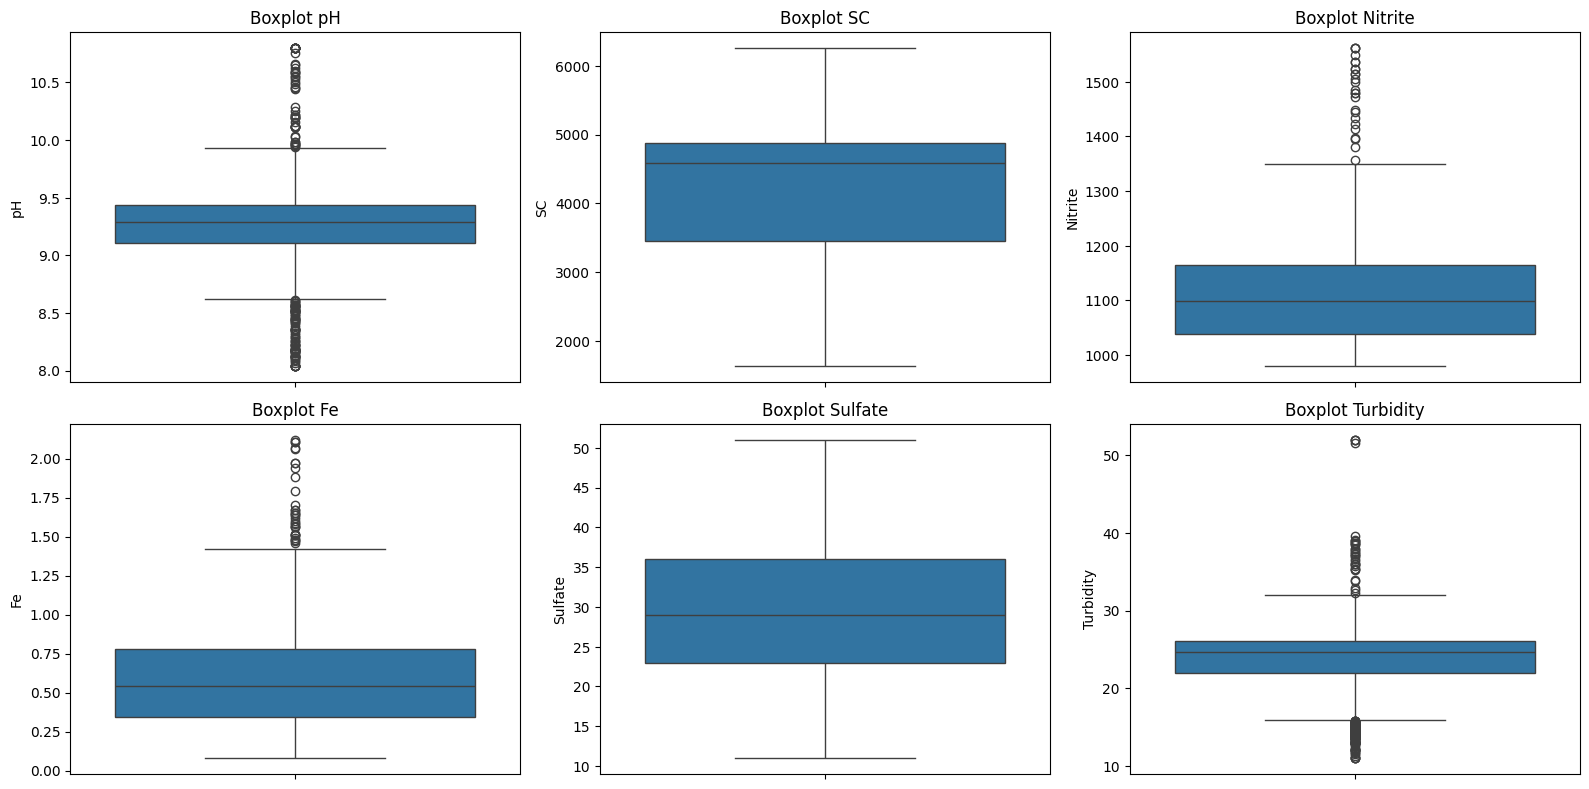

In [12]:
# ============================================================
# VISUALISASI BOXPLOT OUTLIER
# ============================================================
print("\n. Visualisasi Outlier")

plt.figure(figsize=(16,8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot {col}')

plt.tight_layout()
plt.show()


Statistik Dataset:
                pH           SC      Nitrite           Fe      Sulfate  \
count  1046.000000  1046.000000  1046.000000  1046.000000  1046.000000   
mean      9.250029  3992.886233  1112.036329     0.589943    28.488528   
std       0.444797  1287.958327    92.663143     0.339790     9.076673   
min       8.040000  1632.000000   980.000000     0.080000    11.000000   
25%       9.110000  3452.750000  1038.500000     0.340000    23.000000   
50%       9.290000  4581.500000  1099.000000     0.540000    29.000000   
75%       9.440000  4873.750000  1164.000000     0.780000    36.000000   
max      10.800000  6262.000000  1562.000000     2.120000    51.000000   

         Turbidity  Target_encoded  
count  1046.000000     1046.000000  
mean     23.568356        0.906310  
std       5.358846        0.291537  
min      11.000000        0.000000  
25%      22.020000        1.000000  
50%      24.670000        1.000000  
75%      26.095000        1.000000  
max      52.00000

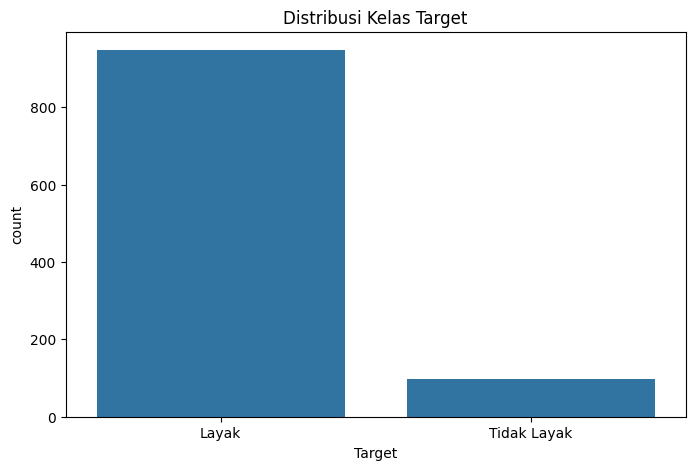

In [13]:
# Statistik deskriptif
print("\nStatistik Dataset:")
print(df.describe())

# Visualisasi distribusi kelas
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Target')
plt.title("Distribusi Kelas Target")
plt.show()


Fitur yang digunakan:
['pH', 'SC', 'Nitrite', 'Fe', 'Sulfate', 'Turbidity']


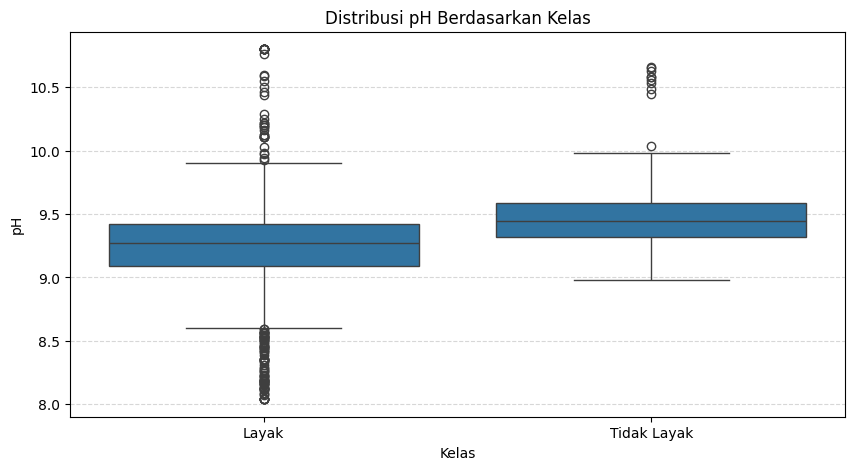

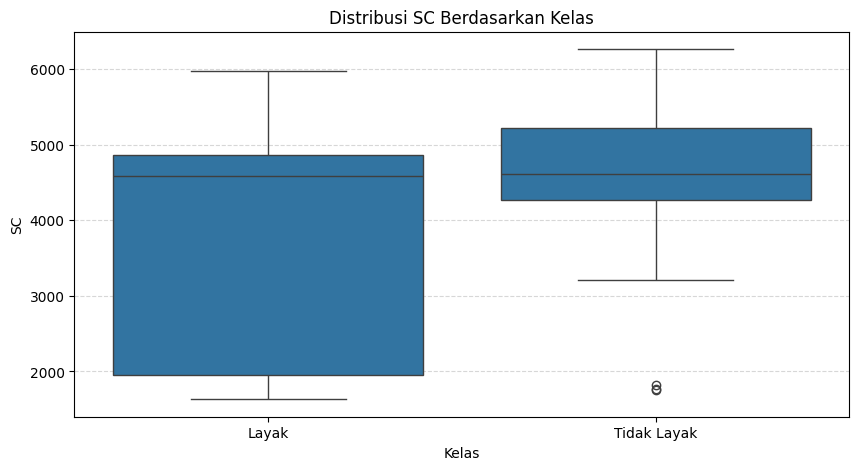

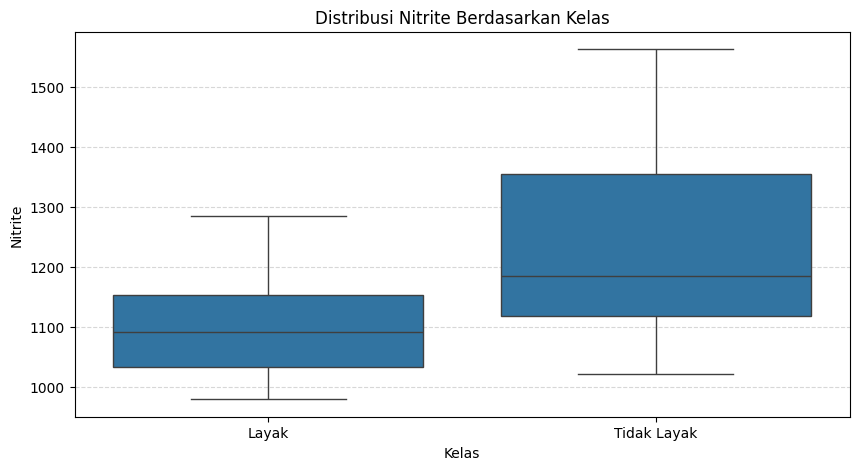

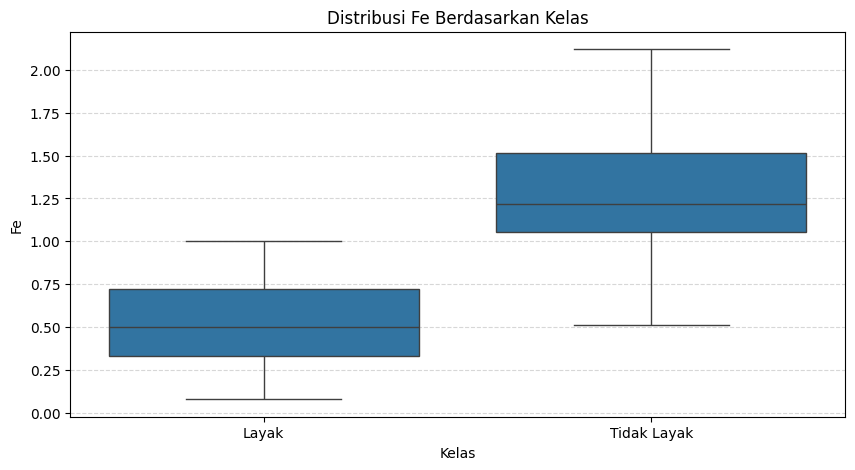

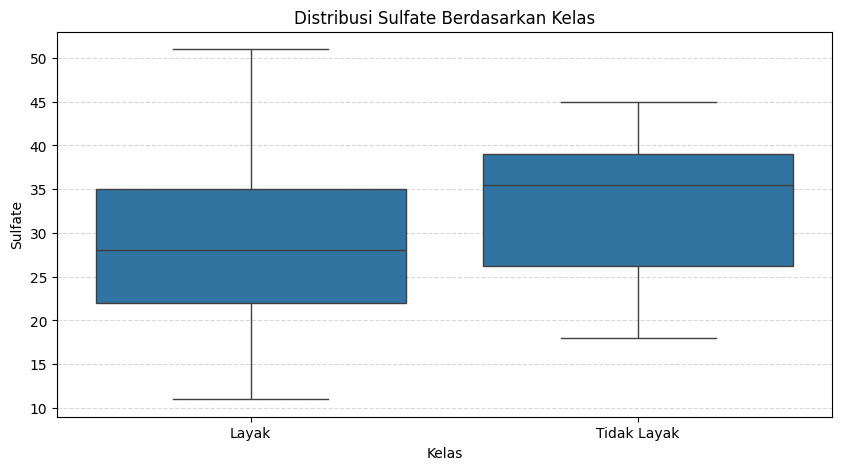

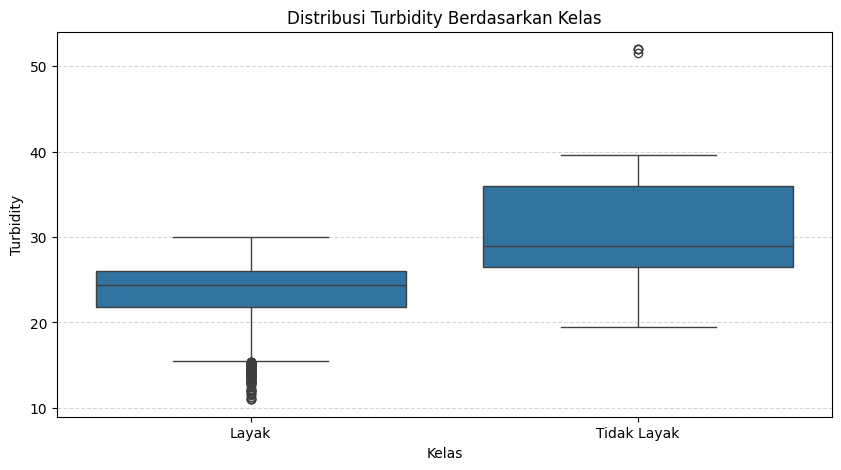

In [14]:
# ============================================================
# PEMISAHAN FITUR DAN TARGET
# ============================================================
X = df.drop(["Target", "Target_encoded"], axis=1)
y = df["Target_encoded"]

print("\nFitur yang digunakan:")
print(X.columns.tolist())


# ============================================================
# - VISUALISASI DISTRIBUSI FITUR PER KELAS
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

fitur = X.columns.tolist()

for kolom in fitur:
    plt.figure(figsize=(10, 5))

    sns.boxplot(
        x='Target',
        y=kolom,
        data=df
    )

    plt.title(f'Distribusi {kolom} Berdasarkan Kelas')
    plt.xlabel('Kelas')
    plt.ylabel(kolom)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

In [15]:
# ============================================================
# SPLIT DATA TRAINING DAN TESTING
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

print("\n" + "="*60)
print("UKURAN DATA")
print("="*60)
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)


UKURAN DATA
X_train : (732, 6)
X_test  : (314, 6)


In [16]:
# ============================================================
# MODEL AWAL RANDOM FOREST
# ============================================================
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

# ============================================================
# CROSS VALIDATION
# ============================================================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=skf,
    scoring='f1'
)

print("\n" + "="*60)
print("HASIL CROSS VALIDATION")
print("="*60)
print("F1-Score tiap fold:")
print(cv_scores)

print("\nRata-rata F1-Score:")
print(cv_scores.mean())


HASIL CROSS VALIDATION
F1-Score tiap fold:
[1.         0.99625468 1.         1.         0.99622642]

Rata-rata F1-Score:
0.9984962193484559


In [17]:
# ============================================================
# HYPERPARAMETER TUNING
# ============================================================
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=skf,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\n" + "="*60)
print("HASIL TUNING")
print("="*60)
print("Best Parameter:")
print(grid.best_params_)


HASIL TUNING
Best Parameter:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [18]:
# ============================================================
# PREDIKSI
# ============================================================
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# ============================================================
# - EVALUASI MODEL
# ============================================================
print("\n" + "="*60)
print("EVALUASI MODEL")
print("="*60)

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("ROC-AUC  :", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


EVALUASI MODEL
Accuracy : 0.9968152866242038
ROC-AUC  : 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        29
           1       1.00      1.00      1.00       285

    accuracy                           1.00       314
   macro avg       1.00      0.98      0.99       314
weighted avg       1.00      1.00      1.00       314



CONFUSION MATRIX
[[ 28   1]
 [  0 285]]


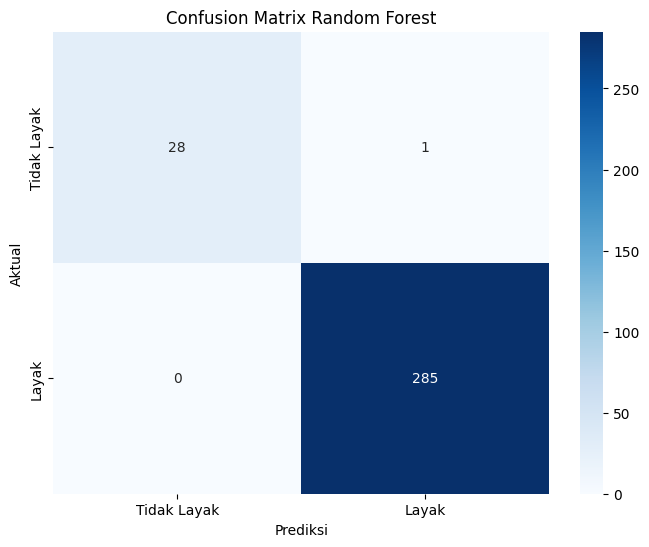

In [19]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("="*50)
print("CONFUSION MATRIX")
print("="*50)
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Tidak Layak', 'Layak'],
    yticklabels=['Tidak Layak', 'Layak']
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Random Forest")
plt.show()

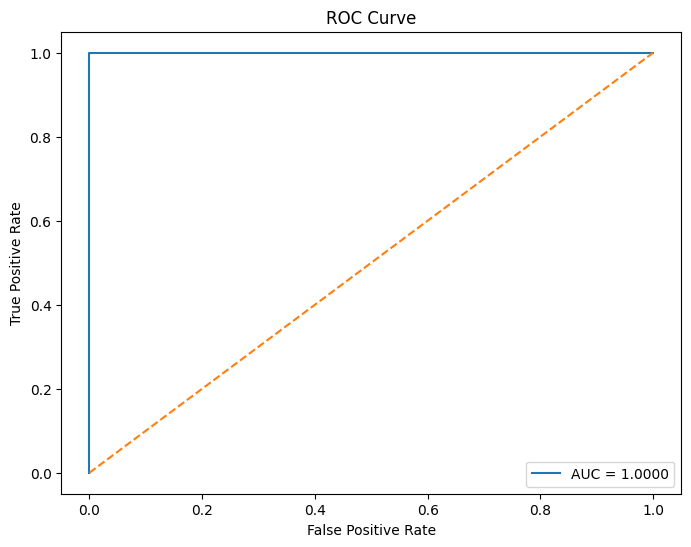

In [20]:
# ============================================================
# ROC CURVE
# ============================================================
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


Feature Importance:
     Feature  Importance
3         Fe    0.548744
5  Turbidity    0.240179
2    Nitrite    0.071793
0         pH    0.067668
1         SC    0.045182
4    Sulfate    0.026434


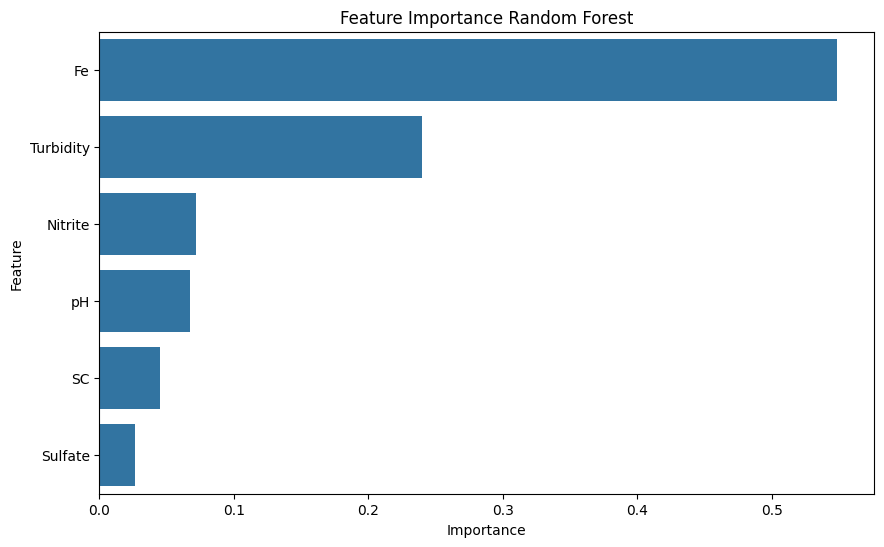

In [21]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================
importance = best_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance Random Forest")
plt.show()



In [22]:
# ============================================================
# KORELASI
# CEK POTENSI DATA LEAKAGE
# ============================================================
print("\n" + "="*60)
print("KORELASI FITUR TERHADAP TARGET")
print("="*60)

print(
    df.corr(numeric_only=True)["Target_encoded"]
    .sort_values(ascending=False)
)


KORELASI FITUR TERHADAP TARGET
Target_encoded    1.000000
SC               -0.161533
Sulfate          -0.171819
pH               -0.219446
Nitrite          -0.431962
Turbidity        -0.440567
Fe               -0.666502
Name: Target_encoded, dtype: float64


In [23]:
# ============================================================
# SAVE MODEL
# ============================================================
joblib.dump(best_model, "Randomforest_cw.pkl")

print("\nModel berhasil disimpan sebagai:")
print("RandomForest_cw.pkl")


Model berhasil disimpan sebagai:
RandomForest_cw.pkl


In [24]:
# =========================
# LOAD MODEL
# =========================
model = joblib.load("RandomForest_cw.pkl")

In [25]:
# =====================================================
# VALIDASI SOP INDUSTRI
# =====================================================

def validasi_sop(data):

    pelanggaran = []

    if not (8 <= data['pH'] <= 11):
        pelanggaran.append(
            f"pH ({data['pH']}) di luar batas 8 - 11"
        )

    if not (0 <= data['SC'] <= 6000):
        pelanggaran.append(
            f"SC ({data['SC']}) di luar batas 0 - 6000"
        )

    if not (500 <= data['Nitrite'] <= 1500):
        pelanggaran.append(
            f"Nitrite ({data['Nitrite']}) di luar batas 500 - 1500"
        )

    if not (0 <= data['Fe'] <= 1):
        pelanggaran.append(
            f"Fe ({data['Fe']}) di luar batas 0 - 1"
        )

    if not (0 <= data['Sulfate'] <= 100):
        pelanggaran.append(
            f"Sulfate ({data['Sulfate']}) di luar batas 0 - 100"
        )

    if not (0 <= data['Turbidity'] <= 30):
        pelanggaran.append(
            f"Turbidity ({data['Turbidity']}) di luar batas 0 - 30"
        )

    if len(pelanggaran) == 0:
        return "Layak", []

    return "Tidak Layak", pelanggaran

In [26]:
# =====================================================
# CONTOH INPUT DATA BARU
# =====================================================

data_baru = {
    
    'pH': 7.2,
    'SC': 4900,
    'Nitrite': 1050,
    'Fe': 0.8,
    'Sulfate': 101,
    'Turbidity': 31

    # 'pH': 5.7,
    # 'SC': 4900,
    # 'Nitrite': 1050,
    # 'Fe': 0.8,
    # 'Sulfate': 101,
    # 'Turbidity': 50

}

# =====================================================
# UBAH KE DATAFRAME
# =====================================================

input_df = pd.DataFrame([data_baru])


In [27]:
# =====================================================
# PREDIKSI RANDOM FOREST + CONFIDENCE SCORE
# =====================================================

prediksi_rf = model.predict(input_df)[0]

# Ambil probabilitas prediksi
probabilitas = model.predict_proba(input_df)[0]

# Confidence score
confidence_score = max(probabilitas) * 100

label_rf = "Layak" if prediksi_rf == 1 else "Tidak Layak"

# =====================================================
# VALIDASI SOP
# =====================================================

hasil_sop, detail_pelanggaran = validasi_sop(data_baru)

# =====================================================
# HASIL SISTEM
# =====================================================

print("\n===================================")
print("HASIL PREDIKSI")
print("===================================")

print("Prediksi Random Forest :", label_rf)
print(f"Confidence Score       : {confidence_score:.2f}%")
print("Validasi SOP           :", hasil_sop)

if hasil_sop == "Tidak Layak":
    print("\nParameter Bermasalah:")
    for pelanggaran in detail_pelanggaran:
        print("-", pelanggaran)


HASIL PREDIKSI
Prediksi Random Forest : Tidak Layak
Confidence Score       : 54.00%
Validasi SOP           : Tidak Layak

Parameter Bermasalah:
- pH (7.2) di luar batas 8 - 11
- Sulfate (101) di luar batas 0 - 100
- Turbidity (31) di luar batas 0 - 30


In [28]:
# =====================================================
# WARNING SYSTEM
# =====================================================

if hasil_sop == "Layak" and label_rf == "Tidak Layak":

    print(
        "\nWARNING: Model mendeteksi potensi anomali meskipun SOP masih terpenuhi."
    )

elif hasil_sop == "Tidak Layak" and label_rf == "Layak":

    print(
        "\nWARNING: SOP industri menyatakan parameter tidak layak."
    )

else:

    print(
        "\nHasil SOP dan Random Forest konsisten."
    )


Hasil SOP dan Random Forest konsisten.
